<a href="https://colab.research.google.com/github/Serragem/ModelagemVQE/blob/main/testeHeH(TwoLocal).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

'2.4.1'

In [ ]:
# Qiskit: métodos básicos
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize


## MÉTODO HEA

## CRIAÇÃO DO DICIONÁRIO ENTRE 0,05 E 2,00

In [ ]:
def obter_hamiltoniano_HeH(R):
    tabela = {
        0.05: {'II': 33.9557, 'IX': -0.1515, 'IZ': -2.4784, 'XX': 0.1412, 'XZ': 0.1515, 'ZZ': 0.2746},
        0.1:  {'II': 13.3605, 'IX': -0.1626, 'IZ': -2.4368, 'XX': 0.2097, 'XZ': 0.1626, 'ZZ': 0.2081},
        0.15: {'II': 6.8232,  'IX': -0.1537, 'IZ': -2.3801, 'XX': 0.2680, 'XZ': 0.1537, 'ZZ': 0.1512},
        0.2:  {'II': 3.6330,  'IX': -0.1405, 'IZ': -2.2899, 'XX': 0.3027, 'XZ': 0.1405, 'ZZ': 0.1176},
        0.25: {'II': 1.7012,  'IX': -0.1324, 'IZ': -2.1683, 'XX': 0.3211, 'XZ': 0.1324, 'ZZ': 0.1010},
        0.3:  {'II': 0.3821,  'IX': -0.1306, 'IZ': -2.0305, 'XX': 0.3303, 'XZ': 0.1306, 'ZZ': 0.0943},
        0.35: {'II': -0.5810, 'IX': -0.1335, 'IZ': -1.8905, 'XX': 0.3344, 'XZ': 0.1335, 'ZZ': 0.0936},
        0.4:  {'II': -1.3119, 'IX': -0.1396, 'IZ': -1.7568, 'XX': 0.3352, 'XZ': 0.1396, 'ZZ': 0.0969},
        0.45: {'II': -1.8796, 'IX': -0.1477, 'IZ': -1.6339, 'XX': 0.3339, 'XZ': 0.1477, 'ZZ': 0.1030},
        0.5:  {'II': -2.3275, 'IX': -0.1570, 'IZ': -1.5236, 'XX': 0.3309, 'XZ': 0.1570, 'ZZ': 0.1115},
        0.55: {'II': -2.6844, 'IX': -0.1669, 'IZ': -1.4264, 'XX': 0.3264, 'XZ': 0.1669, 'ZZ': 0.1218},
        0.6:  {'II': -2.9708, 'IX': -0.1770, 'IZ': -1.3418, 'XX': 0.3206, 'XZ': 0.1770, 'ZZ': 0.1339},
        0.65: {'II': -3.2020, 'IX': -0.1871, 'IZ': -1.2691, 'XX': 0.3135, 'XZ': 0.1871, 'ZZ': 0.1475},
        0.7:  {'II': -3.3893, 'IX': -0.1968, 'IZ': -1.2073, 'XX': 0.3052, 'XZ': 0.1968, 'ZZ': 0.1626},
        0.75: {'II': -3.5417, 'IX': -0.2060, 'IZ': -1.1552, 'XX': 0.2958, 'XZ': 0.2060, 'ZZ': 0.1791},
        0.8:  {'II': -3.6660, 'IX': -0.2145, 'IZ': -1.1117, 'XX': 0.2853, 'XZ': 0.2145, 'ZZ': 0.1968},
        0.85: {'II': -3.7675, 'IX': -0.2222, 'IZ': -1.0758, 'XX': 0.2738, 'XZ': 0.2222, 'ZZ': 0.2157},
        0.9:  {'II': -3.8505, 'IX': -0.2288, 'IZ': -1.0466, 'XX': 0.2613, 'XZ': 0.2288, 'ZZ': 0.2356},
        0.95: {'II': -3.9183, 'IX': -0.2343, 'IZ': -1.0233, 'XX': 0.2481, 'XZ': 0.2343, 'ZZ': 0.2564},
        1:    {'II': -3.9734, 'IX': -0.2385, 'IZ': -1.0052, 'XX': 0.2343, 'XZ': 0.2385, 'ZZ': 0.2779},
        1.05: {'II': -4.0180, 'IX': -0.2414, 'IZ': -0.9916, 'XX': 0.2199, 'XZ': 0.2414, 'ZZ': 0.3000},
        1.1:  {'II': -4.0539, 'IX': -0.2430, 'IZ': -0.9820, 'XX': 0.2053, 'XZ': 0.2430, 'ZZ': 0.3225},
        1.15: {'II': -4.0825, 'IX': -0.2431, 'IZ': -0.9758, 'XX': 0.1904, 'XZ': 0.2431, 'ZZ': 0.3451},
        1.2:  {'II': -4.1050, 'IX': -0.2418, 'IZ': -0.9725, 'XX': 0.1756, 'XZ': 0.2418, 'ZZ': 0.3678},
        1.25: {'II': -4.1224, 'IX': -0.2392, 'IZ': -0.9716, 'XX': 0.1610, 'XZ': 0.2392, 'ZZ': 0.3902},
        1.3:  {'II': -4.1356, 'IX': -0.2353, 'IZ': -0.9728, 'XX': 0.1466, 'XZ': 0.2353, 'ZZ': 0.4123},
        1.35: {'II': -4.1454, 'IX': -0.2301, 'IZ': -0.9757, 'XX': 0.1327, 'XZ': 0.2301, 'ZZ': 0.4339},
        1.4:  {'II': -4.1523, 'IX': -0.2239, 'IZ': -0.9798, 'XX': 0.1194, 'XZ': 0.2239, 'ZZ': 0.4549},
        1.45: {'II': -4.1568, 'IX': -0.2167, 'IZ': -0.9850, 'XX': 0.1068, 'XZ': 0.2167, 'ZZ': 0.4751},
        1.5:  {'II': -4.1594, 'IX': -0.2086, 'IZ': -0.9910, 'XX': 0.0948, 'XZ': 0.2086, 'ZZ': 0.4945},
        1.55: {'II': -4.1605, 'IX': -0.1998, 'IZ': -0.9975, 'XX': 0.0837, 'XZ': 0.1998, 'ZZ': 0.5129},
        1.6:  {'II': -4.1602, 'IX': -0.1905, 'IZ': -1.0045, 'XX': 0.0734, 'XZ': 0.1905, 'ZZ': 0.5304},
        1.65: {'II': -4.1589, 'IX': -0.1807, 'IZ': -1.0116, 'XX': 0.0640, 'XZ': 0.1807, 'ZZ': 0.5468},
        1.7:  {'II': -4.1568, 'IX': -0.1707, 'IZ': -1.0189, 'XX': 0.0555, 'XZ': 0.1707, 'ZZ': 0.5622},
        1.75: {'II': -4.1540, 'IX': -0.1605, 'IZ': -1.0262, 'XX': 0.0479, 'XZ': 0.1605, 'ZZ': 0.5766},
        1.8:  {'II': -4.1508, 'IX': -0.1503, 'IZ': -1.0334, 'XX': 0.0410, 'XZ': 0.1503, 'ZZ': 0.5899},
        1.85: {'II': -4.1471, 'IX': -0.1403, 'IZ': -1.0404, 'XX': 0.0350, 'XZ': 0.1403, 'ZZ': 0.6023},
        1.9:  {'II': -4.1431, 'IX': -0.1305, 'IZ': -1.0473, 'XX': 0.0297, 'XZ': 0.1305, 'ZZ': 0.6138},
        1.95: {'II': -4.1390, 'IX': -0.1210, 'IZ': -1.0540, 'XX': 0.0251, 'XZ': 0.1210, 'ZZ': 0.6244},
        2:    {'II': -4.1347, 'IX': -0.1119, 'IZ': -1.0605, 'XX': 0.0212, 'XZ': 0.1119, 'ZZ': 0.6342}
    }

    if R not in tabela:
        raise ValueError(f"R={R} não mapeado.")

    d = tabela[R]
    opers = ['II', 'XI', 'IX', 'ZI', 'IZ', 'XX', 'ZZ', 'XZ', 'ZX']
    coefs = [d['II'], d['IX'], d['IX'], d['IZ'], d['IZ'], d['XX'], d['ZZ'], d['XZ'], d['XZ']]
    return SparsePauliOp(opers, coefs)

##CONFIGURAÇÃO DO VQE E LOOP

In [ ]:
ansatz = TwoLocal(num_qubits=2, rotation_blocks=['rx', 'rz'],
                  entanglement_blocks='cz', reps=1)

estimator = StatevectorEstimator()
distancias = sorted(list(np.arange(0.05, 2.05, 0.05)))
distancias = [round(r, 2) if r*100 % 10 != 5 else round(r, 3) for r in distancias]
distancias = [0.05 if r == 0.05 else r for r in distancias]

energias_hartree = []
ponto_inicial = np.zeros(ansatz.num_parameters)

for R in distancias:
    try:
        H = obter_hamiltoniano_HeH(R)
        res = minimize(lambda p, a, h, e: e.run([(a, h, p)]).result()[0].data.evs,
                       ponto_inicial, args=(ansatz, H, estimator),
                       method='COBYLA', tol=1e-6)
        energias_hartree.append(res.fun / 2)
        ponto_inicial = res.x
        print(f"R: {R:.2f} | E: {res.fun/2:.4f} Ha")
    except ValueError:
        continue

/tmp/ipykernel_12690/3972180657.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=2, rotation_blocks=['rx', 'rz'],


R: 0.05 | E: 14.6367 Ha
R: 0.10 | E: 4.3475 Ha
R: 0.15 | E: 1.1071 Ha
R: 0.20 | E: -0.4146 Ha
R: 0.25 | E: -1.2672 Ha
R: 0.30 | E: -1.7923 Ha
R: 0.35 | E: -2.1342 Ha
R: 0.40 | E: -2.3643 Ha
R: 0.45 | E: -2.5222 Ha
R: 0.50 | E: -2.6316 Ha
R: 0.55 | E: -2.7077 Ha
R: 0.60 | E: -2.7603 Ha
R: 0.65 | E: -2.7964 Ha
R: 0.70 | E: -2.8207 Ha
R: 0.75 | E: -2.8365 Ha
R: 0.80 | E: -2.8463 Ha
R: 0.85 | E: -2.8517 Ha
R: 0.90 | E: -2.8541 Ha
R: 0.95 | E: -2.8543 Ha
R: 1.00 | E: -2.8530 Ha
R: 1.05 | E: -2.8506 Ha
R: 1.10 | E: -2.8477 Ha
R: 1.15 | E: -2.8445 Ha
R: 1.20 | E: -2.8411 Ha
R: 1.25 | E: -2.8377 Ha
R: 1.30 | E: -2.8345 Ha
R: 1.35 | E: -2.8315 Ha
R: 1.40 | E: -2.8285 Ha
R: 1.45 | E: -2.8259 Ha
R: 1.50 | E: -2.8235 Ha
R: 1.55 | E: -2.8213 Ha
R: 1.60 | E: -2.8194 Ha
R: 1.65 | E: -2.8177 Ha
R: 1.70 | E: -2.8162 Ha
R: 1.75 | E: -2.8149 Ha
R: 1.80 | E: -2.8139 Ha
R: 1.85 | E: -2.8128 Ha
R: 1.90 | E: -2.8120 Ha
R: 1.95 | E: -2.8113 Ha
R: 2.00 | E: -2.8108 Ha


## GRÁFICO

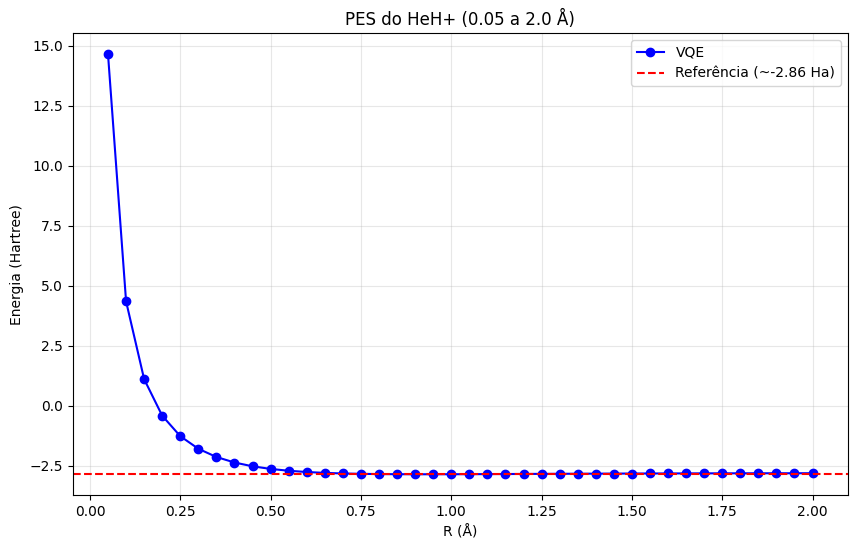

In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(distancias[:len(energias_hartree)], energias_hartree, 'b-o', label='VQE')
plt.axhline(y=-2.8625, color='r', linestyle='--', label='Referência (~-2.86 Ha)')
plt.title('PES do HeH+ (0.05 a 2.0 Å)')
plt.xlabel('R (Å)')
plt.ylabel('Energia (Hartree)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()